# Shared Image Intersection (MEG ↔ fMRI)

Hypothesis 3 focuses on cross-modal retrieval (MEG embeddings retrieving fMRI embeddings).
To evaluate this modality conversion without trial-level pairing, we must evaluate at the **image level**.

This notebook parses all MEG and fMRI events, extracts the unique `image_id`s presented in each dataset, computes their intersection, and saves the matching subset as `shared_images.txt`.

In [1]:
import os
import sys
from pathlib import Path
import yaml
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Add parent directory to path
sys.path.append(os.path.abspath('..'))

### Load Configuration

In [2]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

meg_dir = Path(".." ) / config["data"]["meg_dir"]
fmri_dir = Path(".." ) / config["data"]["fmri_dir"]

### 1. Extract MEG Images
We parse the MEG `events.tsv` files. Since `meg_loader.py` demonstrated that MEG image IDs are stored numerically in the `value` column, we will extract that.

In [3]:
meg_image_ids = set()

meg_event_files = list(meg_dir.rglob("*events.tsv"))
print(f"Found {len(meg_event_files)} MEG event files.")

for event_file in meg_event_files:
    df = pd.read_csv(event_file, sep='\t', encoding='latin-1', on_bad_lines='skip', engine='python')
    if 'value' in df.columns:
        # Extract valid integer values corresponding to image conditions
        valid_values = df.loc[df['value'].notna(), 'value'].astype(int)
        valid_values = valid_values[valid_values > 0]
        
        # The loader uses the raw int as a string for the image_id
        meg_image_ids.update((str(v) for v in valid_values))

print(f"Extract complete. Total unique MEG Images: {len(meg_image_ids)}")

Found 481 MEG event files.
Extract complete. Total unique MEG Images: 22448


### 2. Extract fMRI Images
We parse the fMRI `stimulus-metadata.tsv` (which are actually CSVs) from the `ICA-betas` derivatives. The ID is the filename stem in the `stimulus` column.

In [4]:
fmri_image_ids = set()

# Search the specific ICA-betas derivative directory first to avoid symlink duplication
beta_dir = fmri_dir / "derivatives" / "ICA-betas"
fmri_event_files = list(beta_dir.rglob("*stimulus-metadata.tsv"))

print(f"Found {len(fmri_event_files)} fMRI event files.")

for event_file in fmri_event_files:
    df = pd.read_csv(event_file, sep=',', encoding='utf-8', on_bad_lines='skip', engine='python')
    if 'stimulus' in df.columns:
        valid_stimuli = df.loc[df['stimulus'].notna(), 'stimulus']
        
        # In fMRI, the stimulus column contains paths like 'dog_12s.jpg'
        # We strip the extension to get the image_id
        fmri_image_ids.update((Path(str(p)).stem for p in valid_stimuli))

print(f"Extract complete. Total unique fMRI Images: {len(fmri_image_ids)}")

Found 3 fMRI event files.
Extract complete. Total unique fMRI Images: 8740


### 3. Resolving the ID Conflict
The MEG dataset recorded numerical indices (e.g. `2351`), while the fMRI dataset recorded the string paths (e.g. `aardvark_01b`). 

To intersect them, we need the unified vocabulary list `image_metadata.npy` from the EEG stimuli folder. It contains `train_img_concepts_THINGS` alongside their string counterparts.

In [5]:
metadata_path = Path("..") / "data" / "things-eeg2" / "stimuli" / "image_metadata.npy"
import numpy as np
metadata = np.load(metadata_path, allow_pickle=True).item()

train_files = [Path(f).stem for f in metadata["train_img_files"]]
test_files = [Path(f).stem for f in metadata["test_img_files"]]
all_files = train_files + test_files

# Create a reverse lookup dictionary.
# In the MEG dataset, value 1 corresponds to all_files[0], value 2 -> all_files[1], etc.
id_to_string_map = {str(i+1): file_stem for i, file_stem in enumerate(all_files)}

# Map the MEG numeric IDs to corresponding strings
mapped_meg_images = set()
for m_id in meg_image_ids:
    if m_id in id_to_string_map:
        mapped_meg_images.add(id_to_string_map[m_id])
        
print(f"Mapped {len(mapped_meg_images)} out of {len(meg_image_ids)} MEG numeric IDs to Strings.")

Mapped 14254 out of 22448 MEG numeric IDs to Strings.


### 4. Compute Intersection & Save


Intersection Results:
Shared format images: 5465


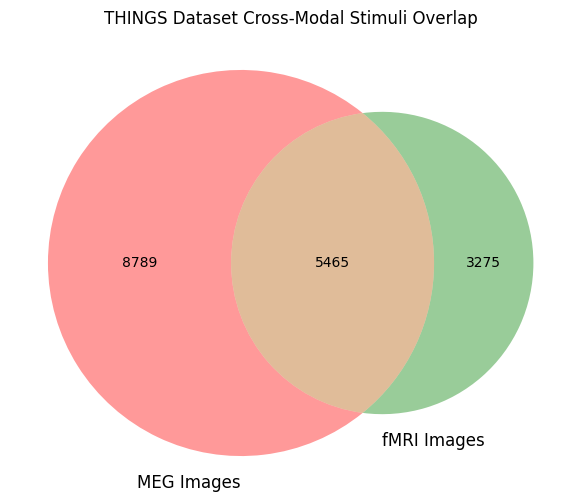

Saved shared cross-modal stimuli list to ../data/shared_images.txt


In [6]:
shared_images = mapped_meg_images.intersection(fmri_image_ids)

print(f"\nIntersection Results:")
print(f"Shared format images: {len(shared_images)}")

plt.figure(figsize=(8, 6))
venn2(subsets=(len(mapped_meg_images - shared_images), 
               len(fmri_image_ids - shared_images), 
               len(shared_images)), 
      set_labels=('MEG Images', 'fMRI Images'))
plt.title("THINGS Dataset Cross-Modal Stimuli Overlap")
plt.show()

out_path = Path("..") / "data" / "shared_images.txt"
with open(out_path, "w") as f:
    for img in sorted(list(shared_images)):
        f.write(f"{img}\n")
        
print(f"Saved shared cross-modal stimuli list to {out_path}")